# Converting photometry table from photometry tools to a light curve

-Example transit light curve of exoplanet WASP-36 b


In [103]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from astropy.time import Time
from astropy.io import fits
from astropy.visualization import ZScaleInterval, ImageNormalize

To create a light curve of your desired object (here we'll use the sample WASP-36 b data stored in the data directory), you must first run the `sort_observations.py` script, then `image_reduction_interact_select.py` (or `image_reduction.py`) with instructions for these included in the README file. 

Then you neet to perform photometry on the reduced images, using your method of choice, though the psf photometry tool in the photomety_analysis directory (either `psf_photometry.py` or `psf_photometry_intselect.py`) is optimized for running photometric calculations across multiple images that will allow you to view your data as a time series.


For this tutorial notebook, we will assume the user has ran the mentioned scripts, and saved the PSF_Photometry_Results to their Reduced data directory. 

In [8]:
path = '../data/WASP36b/Reduced/' #Replace with your own path to the data directory if needed

## Reading in your photometric data

In [2]:
!pwd

/Users/bencapistrant/Documents/GitHub/rho_data_reduction_pipeline/sample_notebooks


In [ ]:
path = '../data/WASP36b/Reduced/' #Replace with your own path to the data directory if needed

In [117]:
phot_table = pd.read_csv(path + 'PSF_Photometry_Results/WASP-36B_psf_photometry.csv')
phot_table

,File,BJD,Flux_Star_1,Flux_err_Star_1,Minst_Star_1,Minst_err_Star_1,Star_1_x,Star_1_y,Flux_Star_2,Flux_err_Star_2,...,Minst_Star_5,Minst_err_Star_5,Star_5_x,Star_5_y,Flux_Star_6,Flux_err_Star_6,Minst_Star_6,Minst_err_Star_6,Star_6_x,Star_6_y
0,WASP36B.2025-02-17.0130_reduced.fits,2.460725e+06,282287.058174,546.174940,-8.186499,0.002101,497,399,308801.136808,569.492139,...,-7.603094,0.002796,501,272,92046.217910,327.977652,-6.969787,0.003869,493,233
1,WASP36B.2025-02-17.0131_reduced.fits,2.460725e+06,276223.552607,543.159044,-8.162924,0.002135,497,399,302276.118992,566.346421,...,-7.580114,0.002853,501,272,90656.878210,330.328849,-6.953274,0.003956,493,233
2,WASP36B.2025-02-17.0132_reduced.fits,2.460725e+06,291172.857882,560.321511,-8.220149,0.002089,497,399,320312.227418,586.132300,...,-7.644034,0.002794,501,272,95297.479967,344.480692,-7.007475,0.003925,493,233
3,WASP36B.2025-02-17.0133_reduced.fits,2.460725e+06,300142.663636,569.830374,-8.253091,0.002061,497,399,328151.306983,593.643089,...,-7.673816,0.002760,501,272,98043.760340,349.230746,-7.038322,0.003867,493,233
4,WASP36B.2025-02-17.0134_reduced.fits,2.460725e+06,288146.853113,554.147136,-8.208807,0.002088,497,399,316063.889791,578.464445,...,-7.628917,0.002782,501,272,93288.241602,334.312134,-6.984339,0.003891,493,233
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,WASP36B.2025-02-17.0192_reduced.fits,2.460725e+06,268471.314830,538.256080,-8.132017,0.002177,497,399,293245.492249,560.540972,...,-7.551860,0.002915,501,272,88192.485448,330.537917,-6.923351,0.004069,493,233
62,WASP36B.2025-02-17.0193_reduced.fits,2.460725e+06,268018.205481,536.161003,-8.130183,0.002172,497,399,291466.693432,557.420500,...,-7.551120,0.002903,501,272,87821.049301,327.066075,-6.918768,0.004044,493,233
63,WASP36B.2025-02-17.0194_reduced.fits,2.460725e+06,261758.224207,530.127765,-8.104523,0.002199,497,399,285489.324974,551.770913,...,-7.532633,0.002929,501,272,85999.005333,324.490283,-6.896005,0.004097,493,233
64,WASP36B.2025-02-17.0195_reduced.fits,2.460725e+06,258392.305390,527.937590,-8.090471,0.002218,497,399,280316.060151,547.987664,...,-7.531230,0.002943,501,272,85463.744868,325.334191,-6.889227,0.004133,493,233


If you'd like to reproduce the following results using the photometry tool, I'll show from my photometry table which reference stars I selected (yellow X's). While your target should hopefully be in the center of your frame, you may need to cross-reference the logbook or Finder images to verify this

In [120]:
N_refs = 5 #Adjust to your number of reference stars

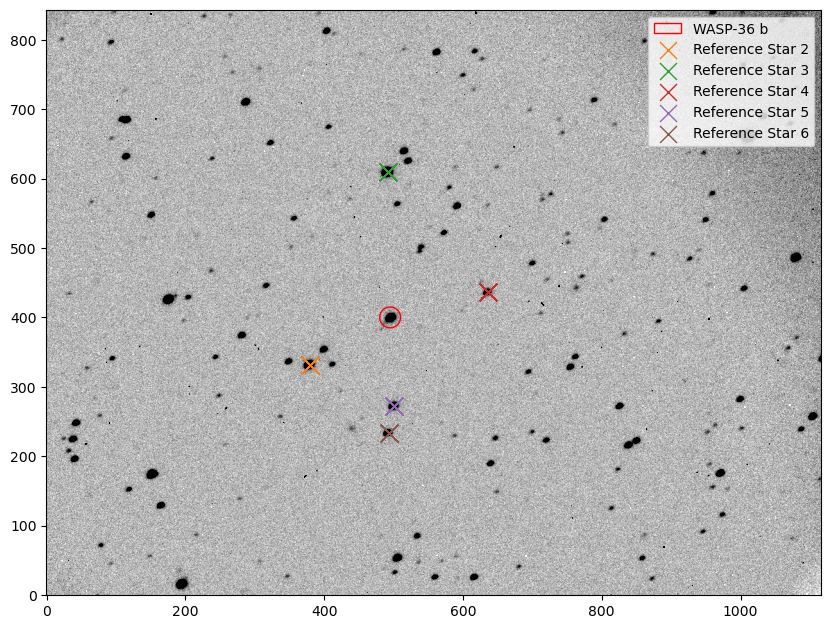

In [ ]:
plt.figure(figsize=(10, 10))
first_image = fits.getdata(path+'WASP-36B/WASP36B.2025-02-17.0130_reduced.fits')
plt.imshow(first_image, origin='lower', cmap='gray_r', norm=ImageNormalize(first_image, interval=ZScaleInterval()))
circle = plt.Circle((495, 400), radius=15, color='red', fill=False, label='WASP-36 b')
plt.gca().add_patch(circle)
plt.scatter(phot_table['Star_1_x'], phot_table['Star_1_y'], marker='x',s=0) #To keep colors consistent for the next plot
for i in range(1,N_refs+1): #Assuming Star 1 is your target
    plt.scatter(phot_table[f'Star_{i+1}_x'], phot_table[f'Star_{i+1}_y'], marker='x',s=150,linewidths=1,label=f'Reference Star {i+1}')
plt.legend()
plt.show()

Lets look at the raw light curves. 

Here the BJD column is time, and for this timeseries we'll be using flux rather than magnitudes for our target and reference stars. It is typically recommended to choose your target star as star 1 when running the psf photometry tool, and I'd recommend at least 3 or more reference stars for generating a clean light curve (here I've selected 5), though this can vary depending on the quality of your observations and choice of stars, as some stars may have their own variable signatures that will contaminate the target light curve upon correcting. Good reference stars will be similar in magnitude to your target and relatively flat light curves (or at least consistent variability due to instrumental or observational variations).

It is for this reason that I suggest first plotting your target and reference light curves:

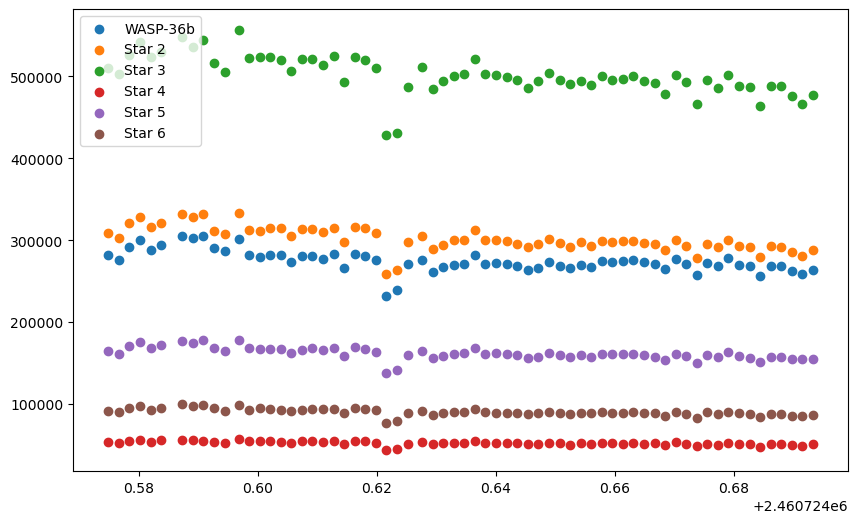

In [128]:
plt.figure(figsize=(10, 6))
plt.scatter(phot_table['BJD'], phot_table['Flux_Star_1'], label='WASP-36b')

for i in range(1,N_refs+1): #Assuming Star 1 is your target
    plt.scatter(phot_table['BJD'],phot_table[f'Flux_Star_{i+1}'],label=f'Star {i+1}')
    plt.legend()    

To correct your targets light curve you will want to divide your target star's flux by some combination of reference star fluxes. You can test how different combinations affect the shape of your resulting light curve to make decisions about what combination to use 

In [157]:
ref_flux = np.array([phot_table[f'Flux_Star_{i+1}'] for i in range(1,N_refs+1)]) #Assuming Star 1 is your target
ref_err = np.sqrt(np.sum(np.array([phot_table[f'Flux_err_Star_{i+1}']**2 for i in range(1,N_refs+1)]), axis=0)) #Don't forget to include errors on your measurements
ref_flux_combined = np.sum(ref_flux, axis=0) 

In [158]:
wasp36_flux = phot_table['Flux_Star_1'] / ref_flux_combined
# simple error propagation for the flux ratio
wasp36_err = wasp36_flux*np.sqrt((phot_table['Flux_err_Star_1']/phot_table['Flux_Star_1'])**2 + (ref_err/ref_flux_combined)**2)

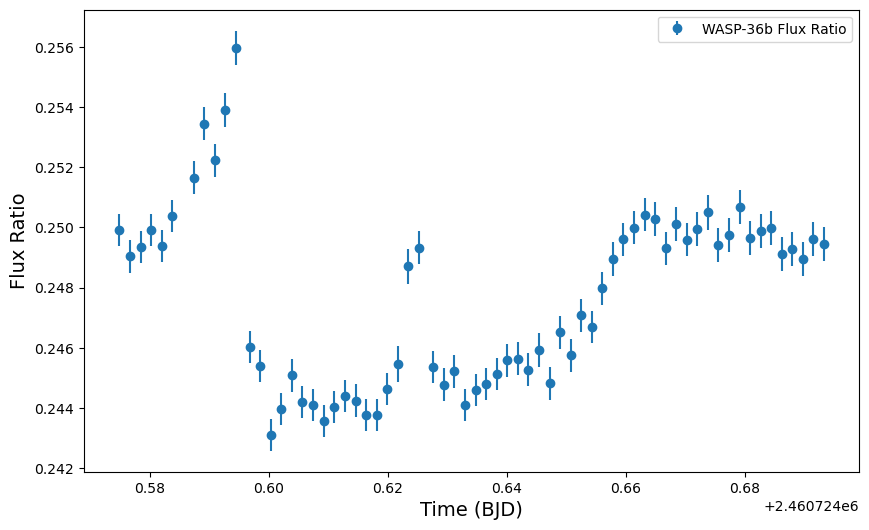

In [159]:
plt.figure(figsize=(10, 6))
plt.errorbar(phot_table['BJD'], wasp36_flux, yerr=wasp36_err, label='WASP-36b Flux Ratio', fmt='o')
plt.xlabel('Time (BJD)',fontsize=14)
plt.ylabel('Flux Ratio',fontsize=14)
plt.legend()
# plt.ylim(0.115,0.13)

Great! I'd say this looks fairly "transit-y" despite some outliers in a couple areas. Looking back at the full reference star light curves, because we see those same features (the spike near planet ingress and spike near mid-transit) in each of the reference star light curves and how they appear to correlate with star magnitude, we can assume these variations are either instrumental or systematic (not astrophysical)

In [ ]:
refs = [2,4,5,6]
select_ref_flux = np.array([phot_table[f'Flux_Star_{i}'] for i in refs])
select_ref_err = np.sqrt(np.sum(np.array([phot_table[f'Flux_err_Star_{i}']**2 for i in refs]),axis=0))
select_ref_flux = select_ref_flux.sum(axis=0)

In [170]:
test_wasp36_flux = phot_table['Flux_Star_1'] / select_ref_flux
# simple error propagation for the flux ratio
select_wasp36_err = test_wasp36_flux*np.sqrt((phot_table['Flux_err_Star_1']/phot_table['Flux_Star_1'])**2 + (ref_err/select_ref_flux)**2)

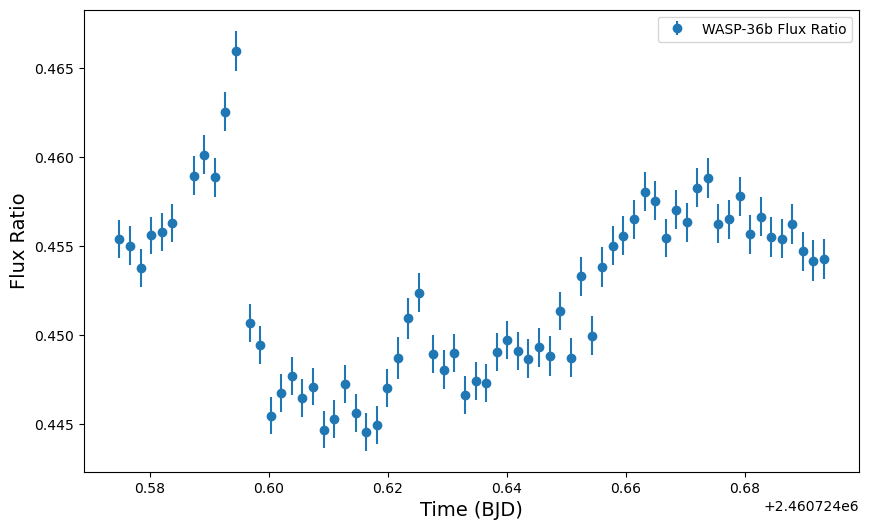

In [171]:
plt.figure(figsize=(10, 6))
plt.errorbar(phot_table['BJD'], test_wasp36_flux, yerr=select_wasp36_err, label='WASP-36b Flux Ratio', fmt='o')
plt.xlabel('Time (BJD)',fontsize=14)
plt.ylabel('Flux Ratio',fontsize=14)
plt.legend()